# Deep SRQ PATH MCP N-player Pool Evaluation

Loads the best Deep SRQ PATH-pool checkpoints, runs self-play evaluation, and evaluates rotated focal-slot matchups against random, IQL, MAPPO, QMIX, and SR-ADIDAS.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [REPO_ROOT, REPO_ROOT / "discrete_action_space", REPO_ROOT / "discrete_action_space" / "lbf_grid"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from discrete_action_space.lbf_grid.robust_notebook_utils import (
    DEFAULT_EVAL_EPISODES,
    DEFAULT_PATH_MCP_NPLAYER_POOL_WORKERS,
    ROBUST_EPSILONS,
    evaluate_deepsrq_path_mcp_pool_suite_for_epsilon,
    robust_lbf_scenarios,
    train_deepsrq_path_mcp_pool_for_epsilon,
)

SCENARIOS = robust_lbf_scenarios()
for scenario in SCENARIOS:
    print(f"{scenario.key}: {scenario.name}")


lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes
lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes
lbf_10x10_3p_8f_levels123: 3 agents with levels 1, 2, and 3, 10x10 grid, 18 foods (3 each for levels 1-6), full sight, 100-step episodes


In [3]:
EVAL_EPISODES = 50 
USE_GPU = True
SRE_SOLVER_WORKERS = DEFAULT_PATH_MCP_NPLAYER_POOL_WORKERS
EVAL_NUM_ENVS = 16

print(f"Evaluation episodes per matchup: {EVAL_EPISODES}")
print(f"PATH MCP N-player pool workers: {SRE_SOLVER_WORKERS}")
print(f"Vectorized evaluation envs: {EVAL_NUM_ENVS}")
print(f"Robust epsilons: {ROBUST_EPSILONS}")


Evaluation episodes per matchup: 50
PATH MCP N-player pool workers: 8
Vectorized evaluation envs: 16
Robust epsilons: (0.01, 0.1, 0.5, 1.0)


## Robust epsilon 0.01

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool vs random | focal slot 1/2:   0%|          | 0/25 [00:0…

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool vs random | focal slot 2/2:   0%|          | 0/25 [00:0…

lbf_8x8_2p_2f_force_coop | deepsrq_path_mcp_nplayer_pool:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | deepsrq_path_mcp_nplayer_pool vs random | focal slot 1/2:   0%|          | 0/25 [00…

lbf_8x8_2p_2f_force_coop | deepsrq_path_mcp_nplayer_pool vs random | focal slot 2/2:   0%|          | 0/25 [00…

RuntimeError: Error(s) in loading state_dict for DuelingSharedTrunkPerAgentJointQNetwork:
	size mismatch for feature.0.weight: copying a param with shape torch.Size([128, 63]) from checkpoint, the shape in current model is torch.Size([128, 99]).

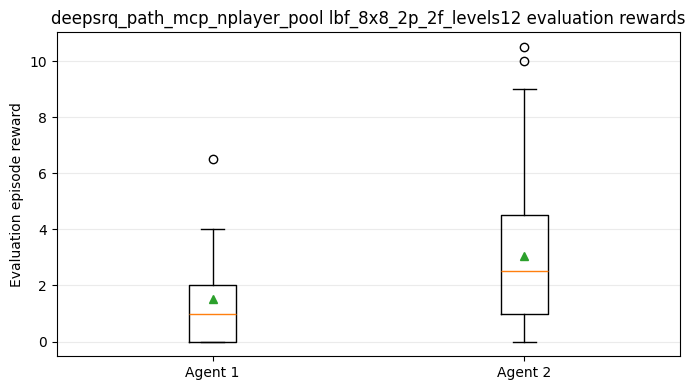

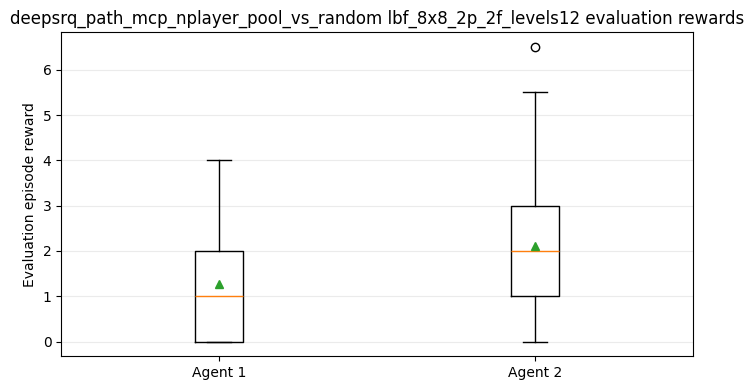

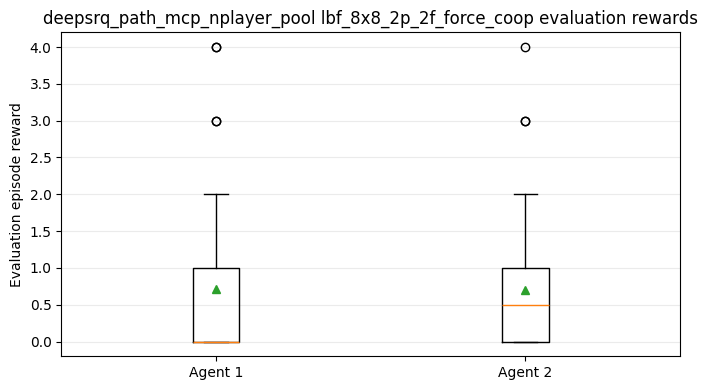

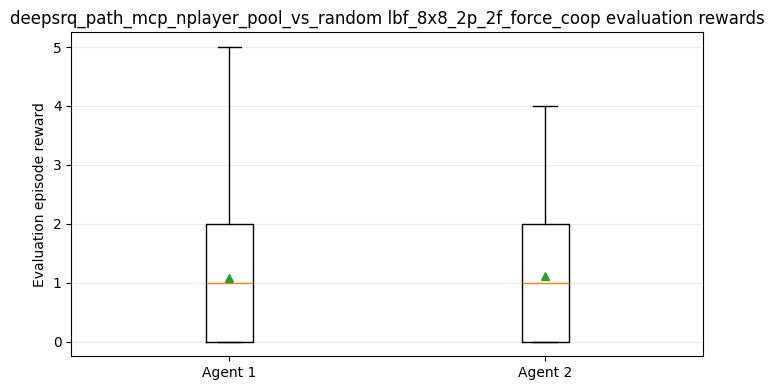

In [4]:
deep_srq_path_pool_eval_eps_0_01 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.01,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
)
deep_srq_path_pool_eval_eps_0_01


## Robust epsilon 0.1

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool vs random | focal slot 1/2:   0%|          | 0/25 [00:0…

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool vs random | focal slot 2/2:   0%|          | 0/25 [00:0…

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool vs iql | focal slot 1/2:   0%|          | 0/25 [00:00<?…

lbf_8x8_2p_2f_levels12 | deepsrq_path_mcp_nplayer_pool vs iql | focal slot 2/2:   0%|          | 0/25 [00:00<?…

...

lbf_10x10_3p_8f_levels123 | deepsrq_path_mcp_nplayer_pool vs random | focal slot 1/3:   0%|          | 0/17 [0…

lbf_10x10_3p_8f_levels123 | deepsrq_path_mcp_nplayer_pool vs random | focal slot 2/3:   0%|          | 0/17 [0…

lbf_10x10_3p_8f_levels123 | deepsrq_path_mcp_nplayer_pool vs random | focal slot 3/3:   0%|          | 0/16 [0…

Process ForkPoolWorker-12:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 387, in get
    res = self._reader.recv_bytes()
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 430, in _recv_bytes
    buf = self._recv(4)
          ^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 395, in _recv
    chunk = read(handle, remaining)
            ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

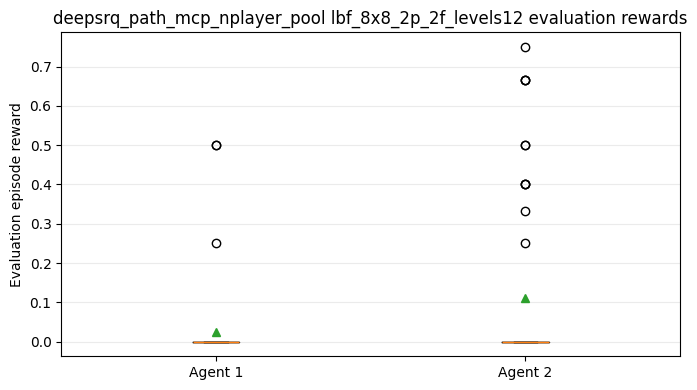

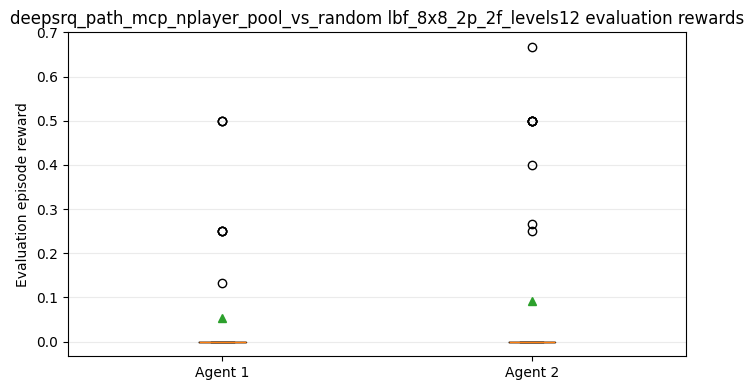

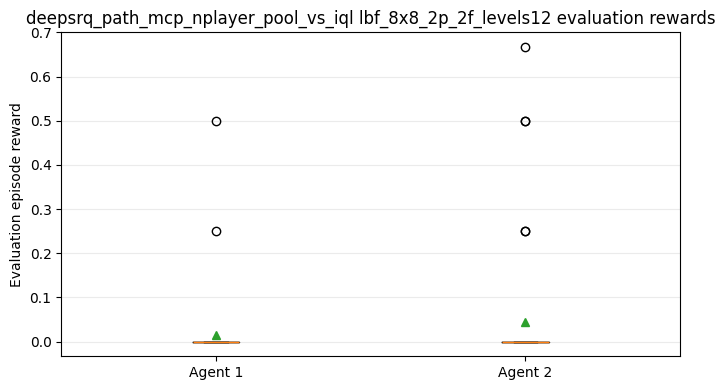

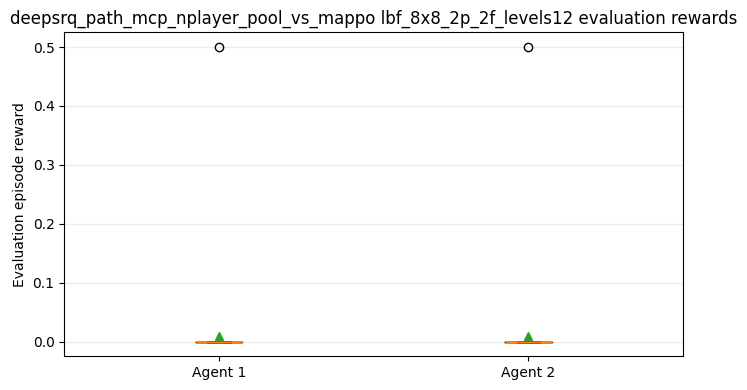

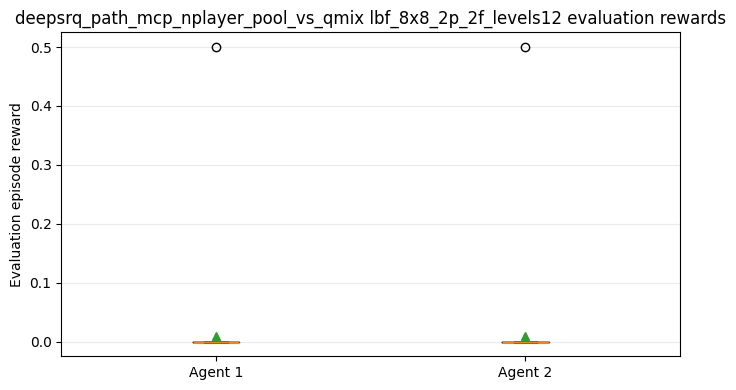

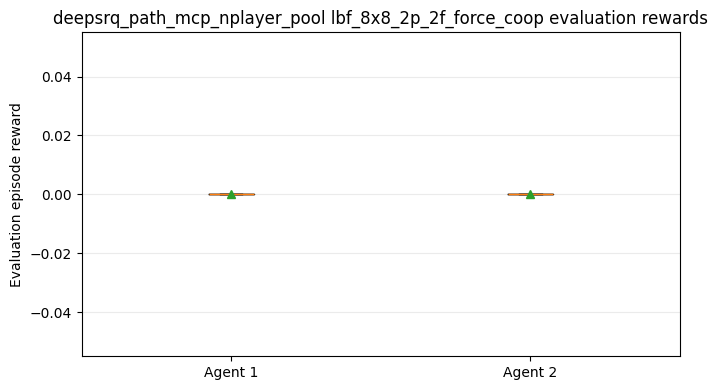

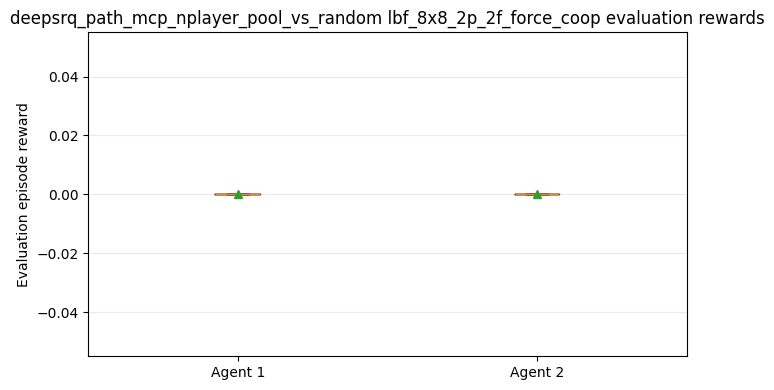

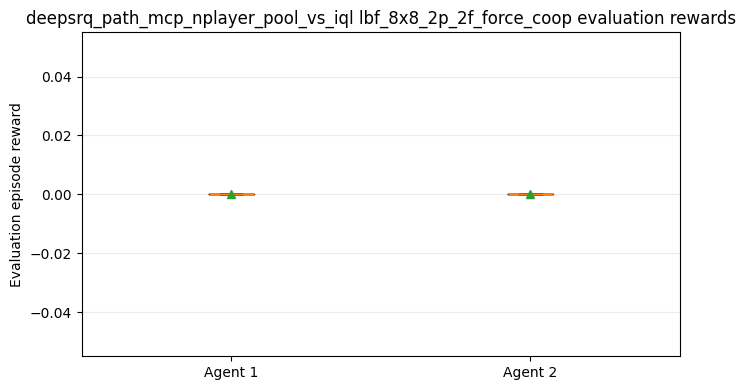

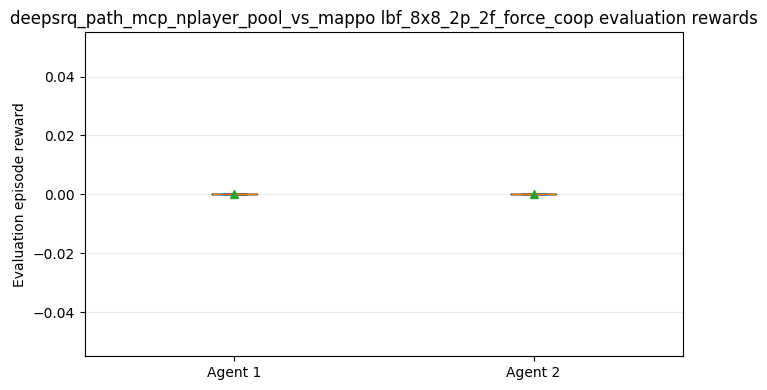

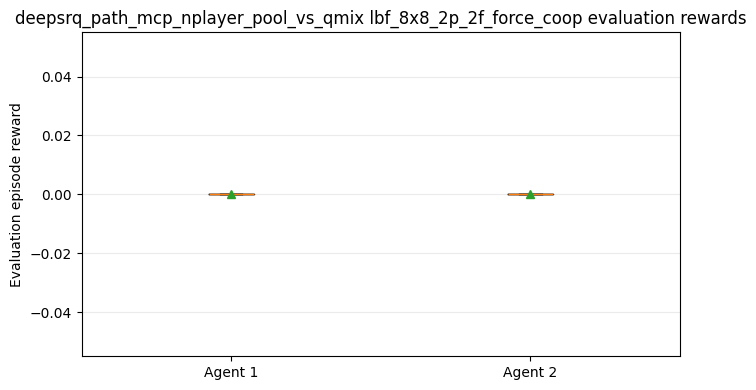

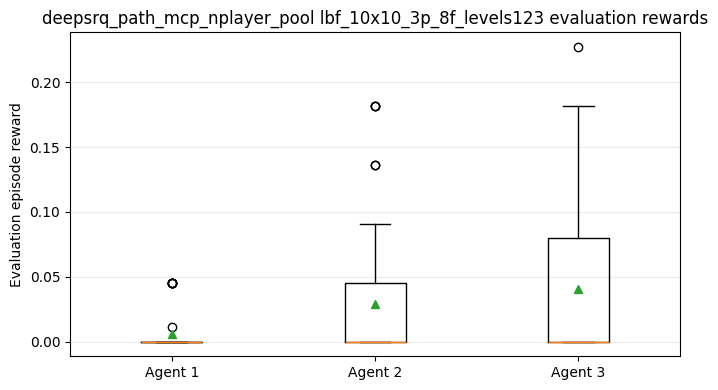

In [ ]:
deep_srq_path_pool_eval_eps_0_1 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.1,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
)
deep_srq_path_pool_eval_eps_0_1


## Robust epsilon 0.5

In [ ]:
deep_srq_path_pool_eval_eps_0_5 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.5,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
)
deep_srq_path_pool_eval_eps_0_5


## Robust epsilon 1

In [ ]:
deep_srq_path_pool_eval_eps_1_0 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    1.0,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
)
deep_srq_path_pool_eval_eps_1_0
